In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sbrn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [14]:
trip_data = pd.read_csv("tripadvisor_review.csv")
trip_data_without_userid = trip_data.drop(columns="User ID")
trip_data_without_userid = trip_data_without_userid.rename(columns={
    "Category 1": "Art Galleries",
    "Category 2": "Dance Clubs",
    "Category 3": "Juice Bars",
    "Category 4": "Restaurants",
    "Category 5": "Museums",
    "Category 6": "Resorts",
    "Category 7": "Parks/Picnic Spots",
    "Category 8": "Beaches",
    "Category 9": "Theaters",
    "Category 10": "Religious Insitutions",
})
print(f"Missing Values in Dataset: {trip_data_without_userid.isna().sum()}")
print(f"Duplicates in Dataset: {trip_data_without_userid.duplicated().sum()}")

Missing Values in Dataset: Art Galleries            0
Dance Clubs              0
Juice Bars               0
Restaurants              0
Museums                  0
Resorts                  0
Parks/Picnic Spots       0
Beaches                  0
Theaters                 0
Religious Insitutions    0
dtype: int64
Duplicates in Dataset: 39


In [15]:
trip_data_without_userid = trip_data_without_userid.drop_duplicates()
print(f"Duplicates in Dataset: {trip_data_without_userid.duplicated().sum()}")

Duplicates in Dataset: 0


<Axes: >

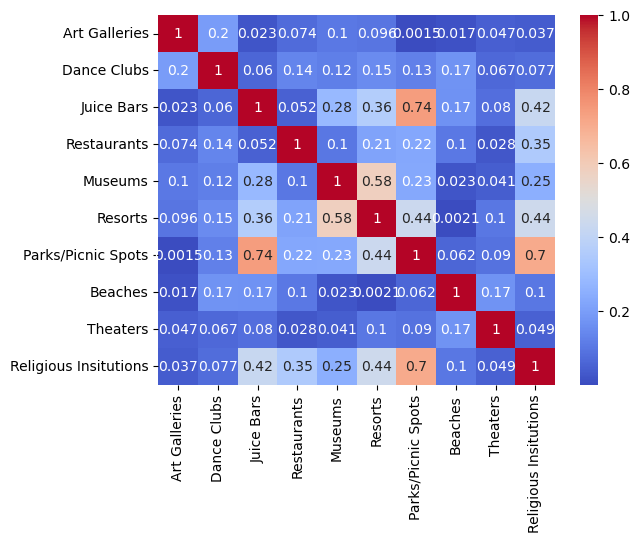

In [16]:
#correlation tests after removing duplicates
correlation_matrix_for_initial_data = trip_data_without_userid.corr().abs()
correlation_matrix_for_initial_data
sbrn.heatmap(correlation_matrix_for_initial_data, annot=True, cmap='coolwarm')

In [17]:
# cleaning and preprocessing the data
mean_of_numerics = trip_data_without_userid.mean(numeric_only=True)
print(mean_of_numerics)

Art Galleries            0.897917
Dance Clubs              1.354899
Juice Bars               0.990903
Restaurants              0.533007
Museums                  0.936706
Resorts                  1.841031
Parks/Picnic Spots       3.180744
Beaches                  2.836854
Theaters                 1.570925
Religious Insitutions    2.804017
dtype: float64


In [18]:
mean_of_numerics_sorted = mean_of_numerics.sort_values(ascending=False)
print(mean_of_numerics_sorted)

Parks/Picnic Spots       3.180744
Beaches                  2.836854
Religious Insitutions    2.804017
Resorts                  1.841031
Theaters                 1.570925
Dance Clubs              1.354899
Juice Bars               0.990903
Museums                  0.936706
Art Galleries            0.897917
Restaurants              0.533007
dtype: float64


In [19]:
mean_of_numerics_sorted = mean_of_numerics_sorted.iloc[:-5]
print(mean_of_numerics_sorted)

Parks/Picnic Spots       3.180744
Beaches                  2.836854
Religious Insitutions    2.804017
Resorts                  1.841031
Theaters                 1.570925
dtype: float64


In [20]:
print(trip_data_without_userid.mean().nlargest(5))

Parks/Picnic Spots       3.180744
Beaches                  2.836854
Religious Insitutions    2.804017
Resorts                  1.841031
Theaters                 1.570925
dtype: float64


In [21]:
trip_data_without_userid.mean().nlargest(5)

Parks/Picnic Spots       3.180744
Beaches                  2.836854
Religious Insitutions    2.804017
Resorts                  1.841031
Theaters                 1.570925
dtype: float64

In [22]:
five_best_features = trip_data_without_userid.mean(numeric_only=True).nlargest(5).index
new_trip_data_without_userid = trip_data_without_userid[five_best_features]
#print(trip_data_without_userid[five_best_features])
new_trip_data_without_userid

,Parks/Picnic Spots,Beaches,Religious Insitutions,Resorts,Theaters
0,3.19,2.79,2.42,2.42,1.82
1,3.21,2.63,2.32,3.18,1.86
2,3.18,2.80,2.50,1.54,1.31
3,3.18,2.96,2.86,1.52,1.57
4,3.18,2.78,2.54,2.02,1.18
...,...,...,...,...,...
975,3.17,2.78,3.20,1.38,0.99
976,3.18,2.79,2.80,1.68,1.34
977,3.17,2.81,3.02,1.78,1.34
978,3.18,2.98,2.46,0.40,1.12


<Axes: >

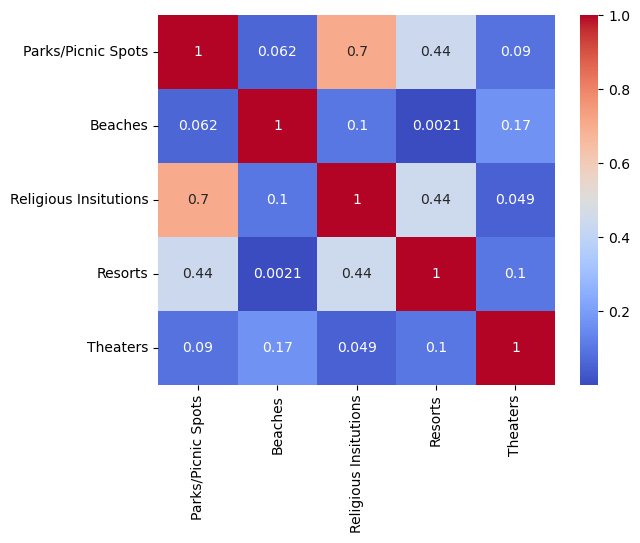

In [23]:
#correlation tests after removing the lowest 5 columns
correlation_matrix_for_initial_data = new_trip_data_without_userid.corr().abs()
correlation_matrix_for_initial_data
sbrn.heatmap(correlation_matrix_for_initial_data, annot=True, cmap='coolwarm')

In [ ]:
# create a package of 3 from the 5 listed features
package_of_three = KMeans(n_clusters=3)